<a href="https://colab.research.google.com/github/karthickb77/IMDB-MOVIES-PREDICTION/blob/main/IMDB_MOVIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [ ]:
print(df.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [ ]:
df = df.dropna(subset=['Rating'])

In [ ]:
df = df.fillna("Unknown")

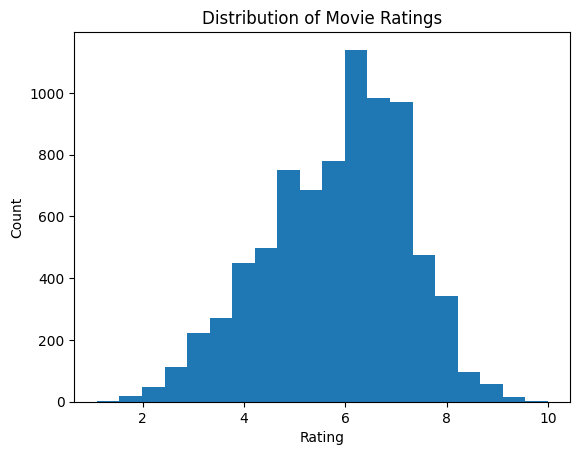

In [ ]:
plt.figure()
plt.hist(df['Rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Movie Ratings")
plt.show()

In [ ]:
df = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3',
         'Duration', 'Votes', 'Rating']]

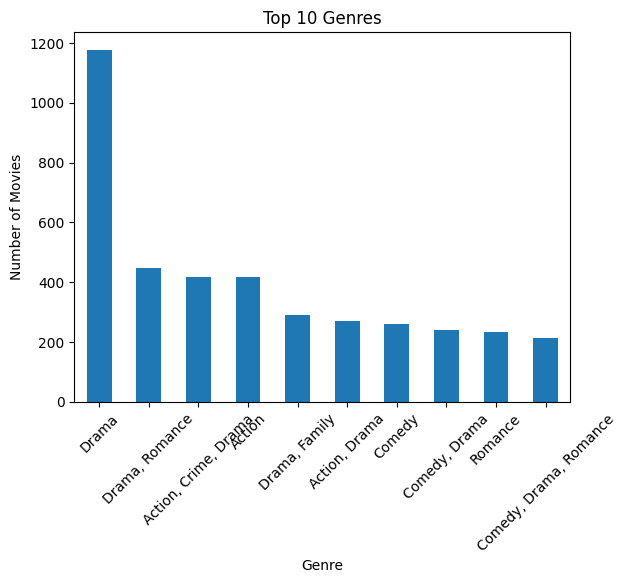

In [ ]:
top_genres = df['Genre'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title("Top 10 Genres")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Duration'] = df['Duration'].str.replace(' min','')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [ ]:
df['Votes'] = df['Votes'].str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

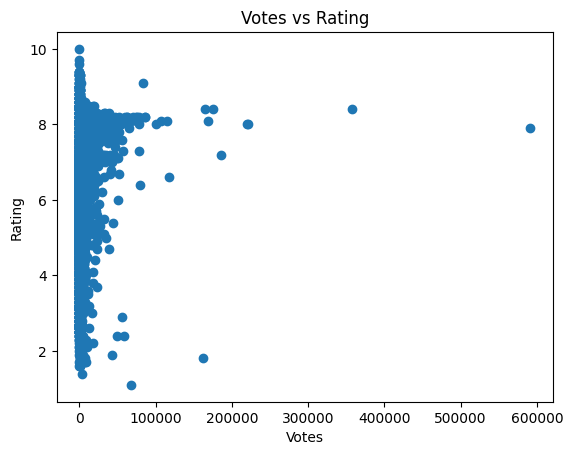

In [ ]:
plt.figure()
plt.scatter(df['Votes'], df['Rating'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

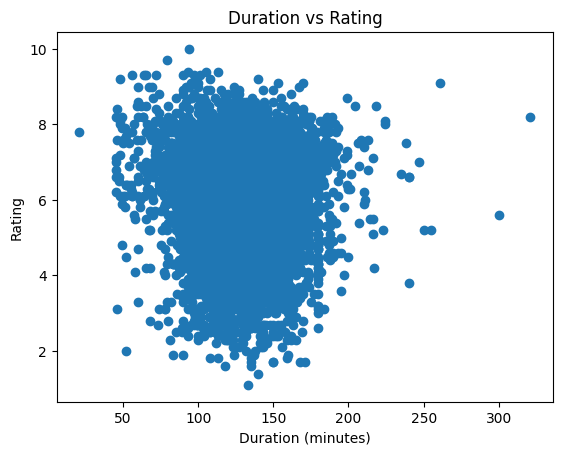

In [ ]:
plt.figure()
plt.scatter(df['Duration'], df['Rating'])
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.title("Duration vs Rating")
plt.show()

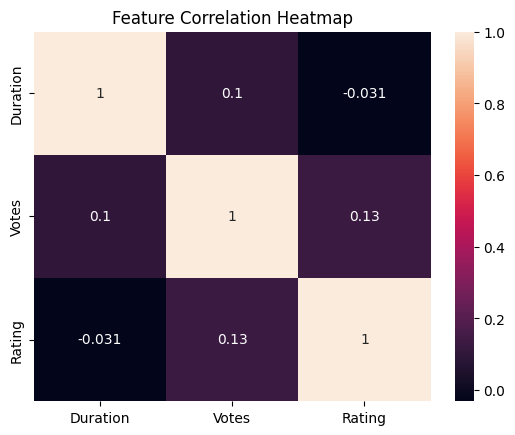

In [ ]:


plt.figure()

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])
df['Actor 3'] = le.fit_transform(df['Actor 3'])

In [ ]:
X = df.drop('Rating', axis=1)
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

In [ ]:
new_movie = [[1, 10, 25, 33, 41, 120, 5000]]
prediction = model.predict(new_movie)
print("Predicted Rating:", prediction)